# Spatial Interpolation

Brendan Harmon  
2026-08-29

This is a gentle introduction to spatial interpolation using GRASS. It
covers binning, Voronoi tessellations, Delaunay triangulation, inverse
weighted distance interpolation, bilinear spline interpolation, bicubic
spline interpolation, regularized spline with tension interpolation, and
cross-validation for parameter optimization. In this tutorial we will
generate a random population of points representing samples of a spatial
phenomena and then interpolate them as a surface using different
methods.

> **Tutorials**
>
> Learn more with Paulo van Breugel’s tutorial on [spatial
> interpolation](https://ecodiv.earth/TutorialsNotes/LegacyNotes/toc/spatial_interpolation.html).

## Setup

Start GRASS in a Cartesian coordinate system.

In [1]:
# Import modules
import os
import sys
import subprocess
from pathlib import Path

# Find GRASS Python packages
sys.path.append(
  subprocess.check_output(
    ["grass", "--config", "python_path"],
    text=True
    ).strip()
  )

# Import GRASS packages
import grass.script as gs
import grass.jupyter as gj
from grass.tools import Tools

# Initialize GRASS session
gs.create_project("interpolation", overwrite=True)
gj.init("interpolation")
tools = Tools(overwrite=True)

# Print projection
projection = tools.g_proj(format="shell", flags="p").keyval
print(projection.get("name"))

## Set region

Set the computational region with
[g.region](https://grass.osgeo.org/grass-stable/manuals/g.region.html).

In [2]:
# Set region
tools.g_region(n=200, s=0, e=800, w=0, res=1)

## Generate random points

Generate a population of random 3-dimensional points for interpolation
using
[v.random](https://grass.osgeo.org/grass-stable/manuals/v.random.html).

In [3]:
# Generate random points
tools.v_random(
    output="points",
    npoints=20,
    zmin=0.0,
    zmax=10.0,
    column="z",
    seed=17,
    flags="z"
    )

# Visualize
m = gj.Map(width=800)
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.show()

<figure>
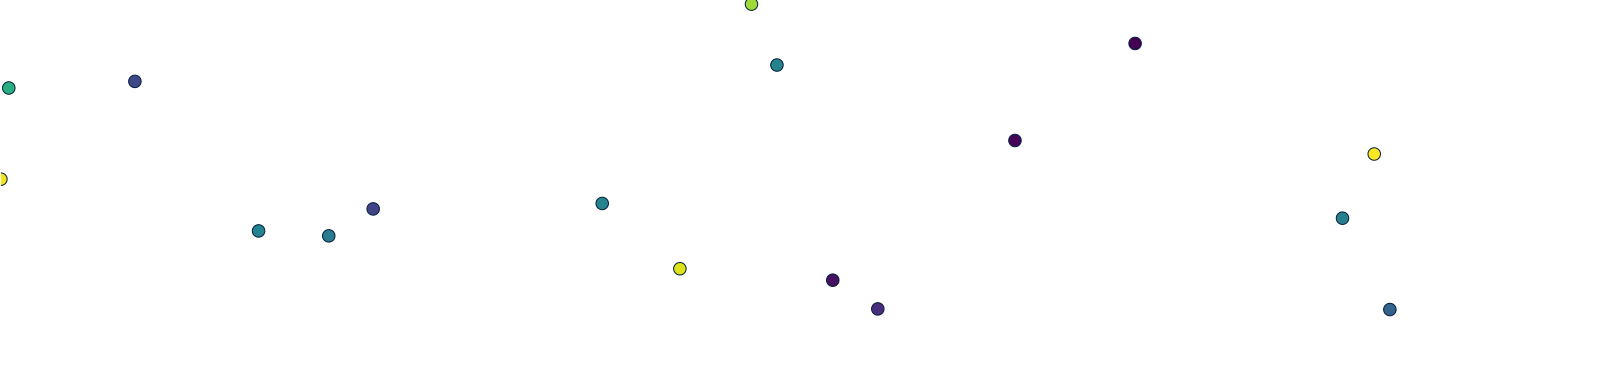
<figcaption aria-hidden="true">Random points</figcaption>
</figure>

## Binning

[v.mkgrid](https://grass.osgeo.org/grass-stable/manuals/v.mkgrid.html)
[v.vect.stats](https://grass.osgeo.org/grass-stable/manuals/v.vect.stats.html)
[v.colors](https://grass.osgeo.org/grass-stable/manuals/v.colors.html)

In [4]:
# Grid
tools.v_mkgrid(map="surface", box=[50, 50], flags="h")

# Sample points
tools.v_vect_stats(
    points="points",
    areas="surface",
    method="average",
    points_column="z",
    count_column="count",
    stats_column="z"
    )

# Set color gradient
tools.v_colors(map="surface", use="attr", column="z", color="viridis")

# Visualize
m = gj.Map(width=800)
m.d_vect(map="surface")
tools.v_colors(map="surface", flags="r")
m.d_vect(map="surface",  color="white", fill="none")
m.d_vect(map="points", icon="basic/point", color="white", fill="white", size=15)
m.show()

<figure>
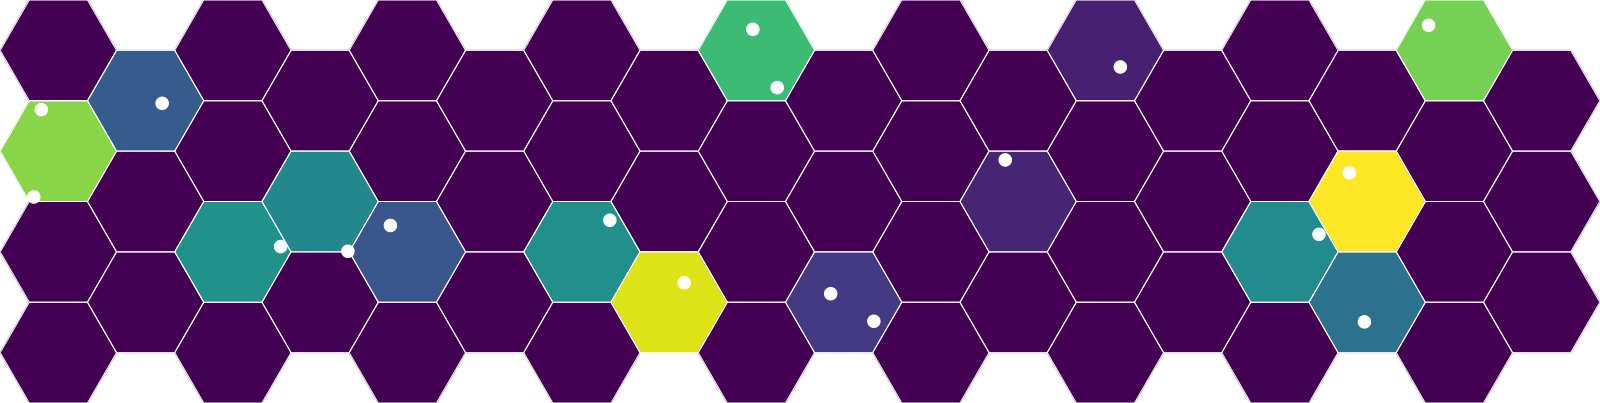
<figcaption aria-hidden="true">Hexagonal binning</figcaption>
</figure>

## Voronoi tessellation

[v.voronoi](https://grass.osgeo.org/grass-stable/manuals/v.voronoi.html)
[v.vect.stats](https://grass.osgeo.org/grass-stable/manuals/v.vect.stats.html)
[v.colors](https://grass.osgeo.org/grass-stable/manuals/v.colors.html)

In [5]:
# Interpolate surface
tools.v_voronoi(input="points", output="surface")

# Sample points
tools.v_vect_stats(
    points="points",
    areas="surface",
    method="average",
    points_column="z",
    count_column="count",
    stats_column="z"
    )

# Set color gradient
tools.v_colors(map="surface", use="attr", column="z", color="viridis")

# Visualize
m = gj.Map(width=800)
m.d_vect(map="surface",  color="white")
tools.v_colors(map="surface", flags="r")
m.d_vect(map="surface",  color="white", fill="none")
m.d_vect(map="points", icon="basic/point", color="white", fill="white", size=15)
m.show()

<figure>
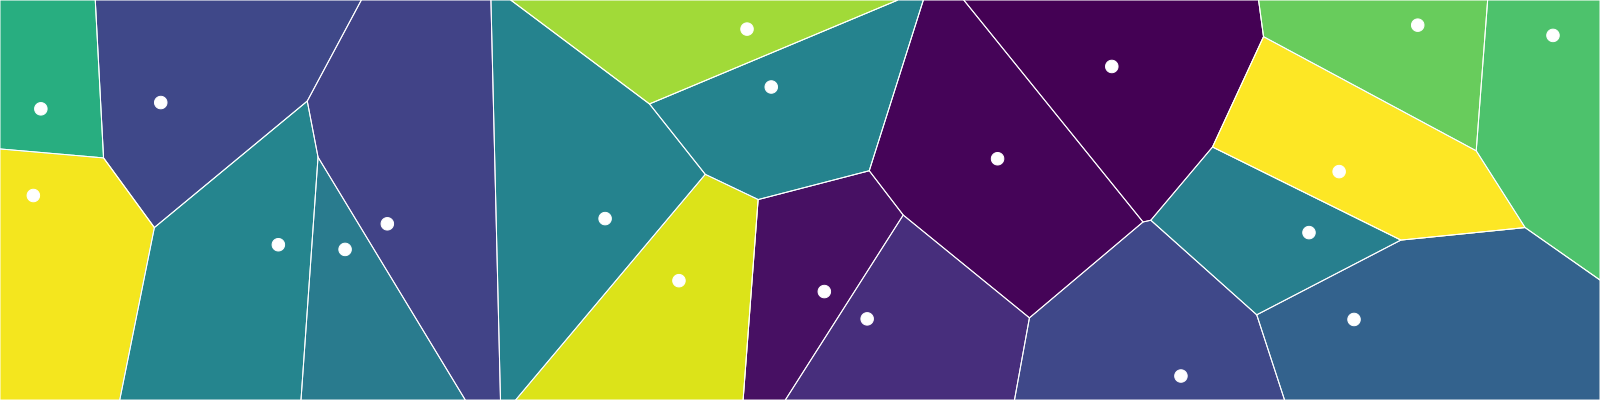
<figcaption aria-hidden="true">Voronoi tessellation</figcaption>
</figure>

## Delaunay triangulation

[v.in.region](https://grass.osgeo.org/grass-stable/manuals/v.in.region.html)
[v.to.points](https://grass.osgeo.org/grass-stable/manuals/v.to.points.html)
[v.patch](https://grass.osgeo.org/grass-stable/manuals/v_patch.html)
[v.delaunay](https://grass.osgeo.org/grass-stable/manuals/v.delaunay.html)
[v.colors](https://grass.osgeo.org/grass-stable/manuals/v.colors.html)

In [6]:
# Sample corners
tools.v_in_region(output="region", type="line")
tools.v_to_points(input="region", output="corners", use="vertex")
tools.v_patch(input=["points", "corners"], output="samples")

# Interpolate surface
tools.v_delaunay(input="samples", output="surface")

# Set color gradient
tools.v_colors(map="surface", use="z", color="viridis")

# Visualize
m = gj.Map(width=800)
m.d_vect(map="surface")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.show()

<figure>
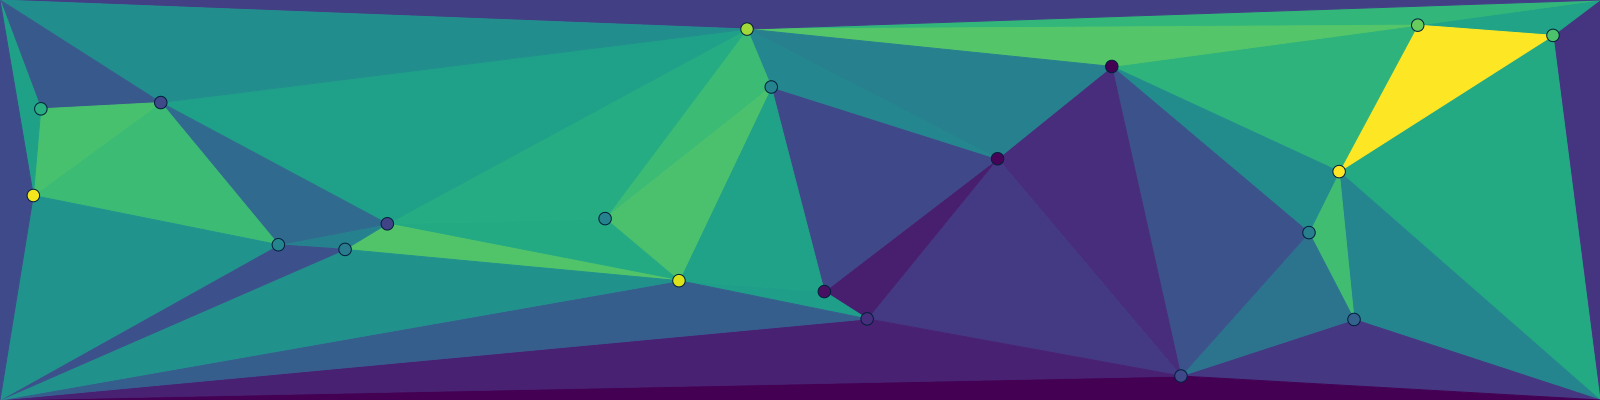
<figcaption aria-hidden="true">Delaunay triangulation</figcaption>
</figure>

## Inverse weighted distance interpolation

[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)
[r.contour](https://grass.osgeo.org/grass-stable/manuals/r.contour.html)
[v.surf.idw](https://grass.osgeo.org/grass-stable/manuals/v.surf.idw.html)

In [7]:
# Interpolate surface
tools.v_surf_idw(input="points", output="surface", power=2.0)

# Set color gradient
tools.r_colors(map="surface", color="viridis")

# Compute contours
tools.r_contour(input="surface", output="contours", step=1)

# Visualize
m = gj.Map(width=800)
m.d_rast(map="surface")
m.d_vect(map="contours", color="white")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.d_legend(raster="surface", at=(5, 95, 1, 3))
m.show()

<figure>
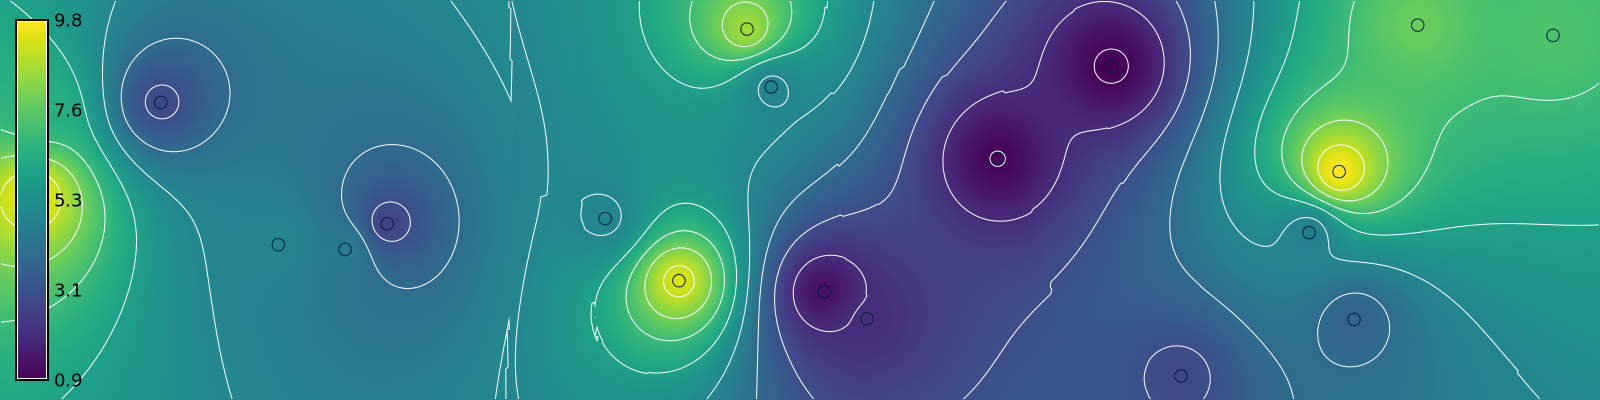
<figcaption aria-hidden="true">Inverse weighted distance
interpolation</figcaption>
</figure>

## Bilinear spline interpolation

[v.surf.bspline](https://grass.osgeo.org/grass-stable/manuals/v.surf.bspline.html)
[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)
[r.contour](https://grass.osgeo.org/grass-stable/manuals/r.contour.html)

In [8]:
# Interpolate surface
tools.v_surf_bspline(
    input="points",
    raster_output="surface",
    method="bilinear",
    ew_step=25,
    ns_step=25
    )

# Set color gradient
tools.r_colors(map="surface", color="viridis")

# Compute contours
tools.r_contour(input="surface", output="contours", step=1)

# Visualize
m = gj.Map(width=800)
m.d_rast(map="surface")
m.d_vect(map="contours", color="white")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.d_legend(raster="surface", at=(5, 95, 1, 3))
m.show()

<figure>
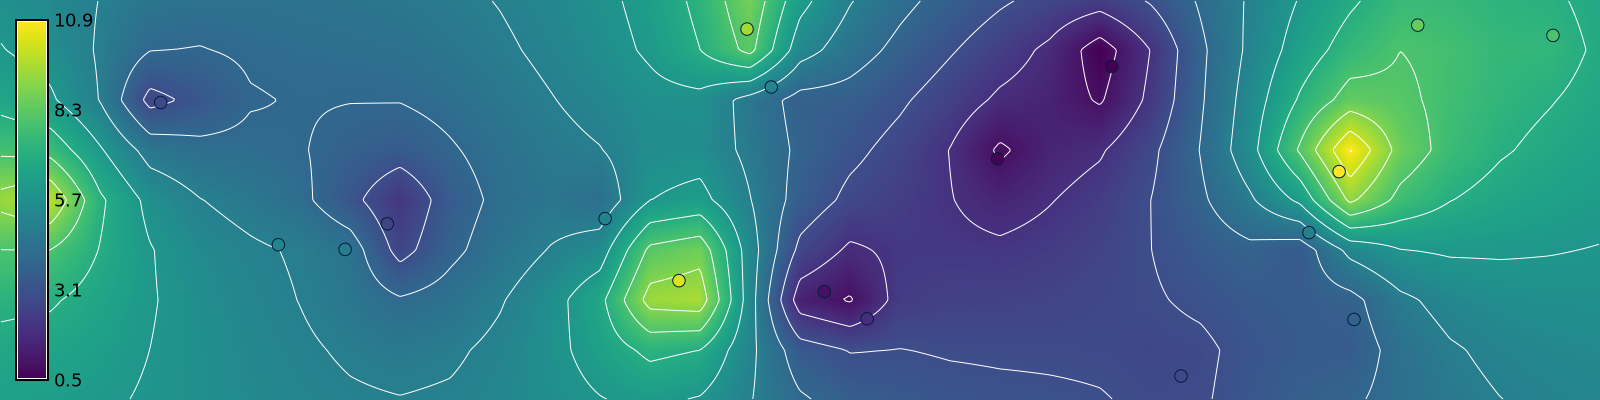
<figcaption aria-hidden="true">Bilinear spline
interpolation</figcaption>
</figure>

## Bicubic spline interpolation

[v.surf.bspline](https://grass.osgeo.org/grass-stable/manuals/v.surf.bspline.html)
[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)
[r.contour](https://grass.osgeo.org/grass-stable/manuals/r.contour.html)

In [9]:
# Interpolate surface
tools.v_surf_bspline(
    input="points",
    raster_output="surface",
    method="bicubic",
    ew_step=25,
    ns_step=25
    )

# Set color gradient
tools.r_colors(map="surface", color="viridis")

# Compute contours
tools.r_contour(input="surface", output="contours", step=1)

# Visualize
m = gj.Map(width=800)
m.d_rast(map="surface")
m.d_vect(map="contours", color="white")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.d_legend(raster="surface", at=(5, 95, 1, 3))
m.show()

<figure>
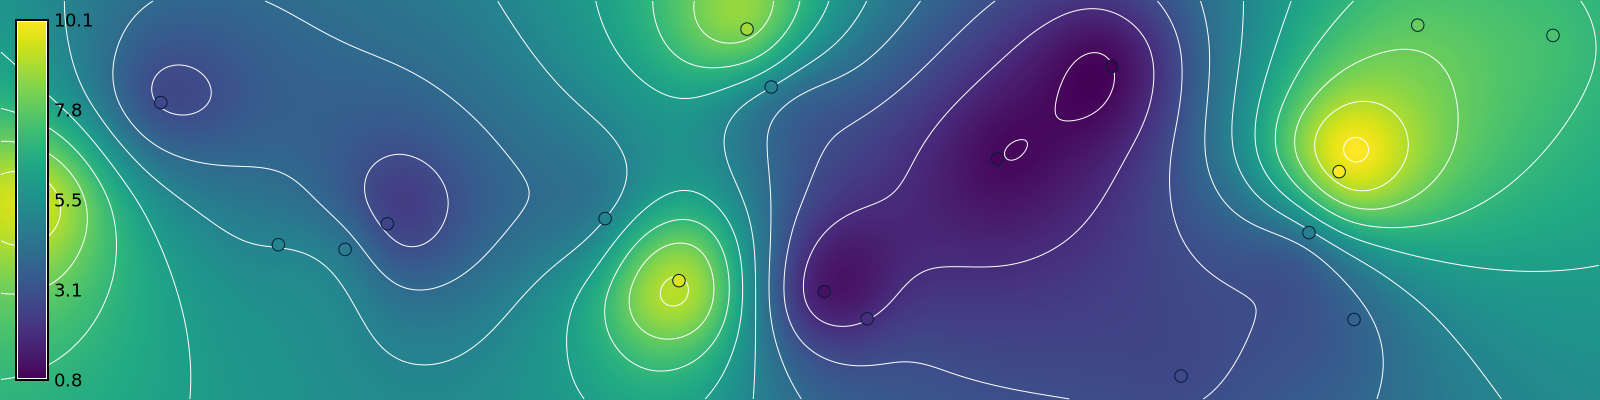
<figcaption aria-hidden="true">Bicubic spline interpolation</figcaption>
</figure>

## Regularized spline with tension interpolation

[v.surf.rst](https://grass.osgeo.org/grass-stable/manuals/v.surf.rst.html)
[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)
[r.contour](https://grass.osgeo.org/grass-stable/manuals/r.contour.html)

In [10]:
# Interpolate surface
tools.v_surf_rst(input="points", elevation="surface", tension=40, flags="t")

# Set color gradient
tools.r_colors(map="surface", color="viridis")

# Compute contours
tools.r_contour(input="surface", output="contours", step=1)

# Visualize
m = gj.Map(width=800)
m.d_rast(map="surface")
m.d_vect(map="contours", color="white")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.d_legend(raster="surface", at=(5, 95, 1, 3))
m.show()

<figure>
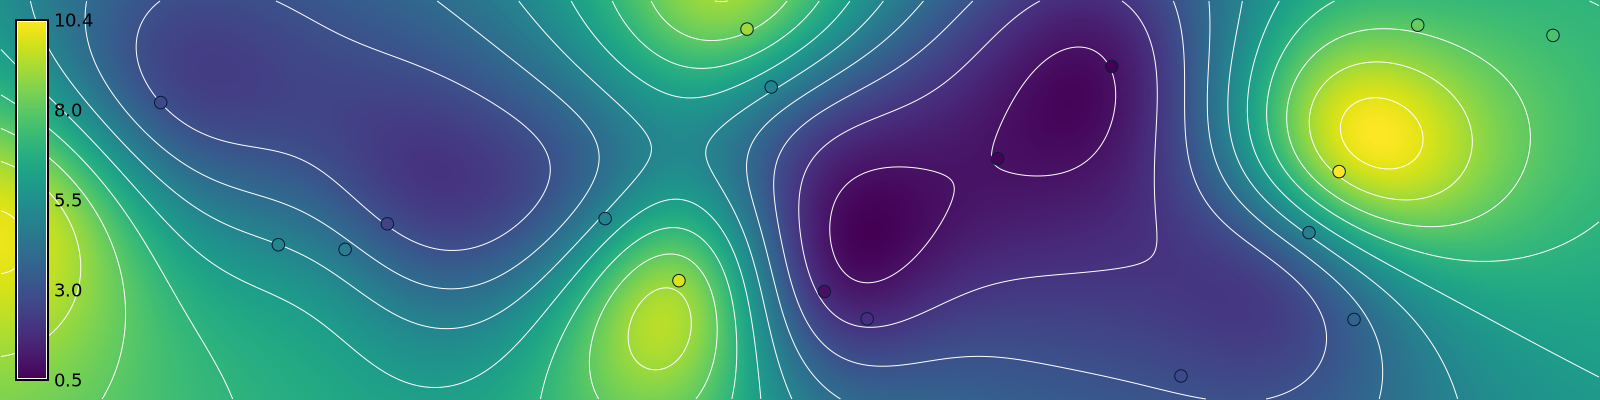
<figcaption aria-hidden="true">Regularized spline with tension
interpolation</figcaption>
</figure>

## Parameter Optimization

[g.extension](https://grass.osgeo.org/grass-stable/manuals/g.extension.html)
[v.surf.rst.cv](https://grass.osgeo.org/grass-stable/manuals/addons/v.surf.rst.cv.html)
[r.colors](https://grass.osgeo.org/grass-stable/manuals/r.colors.html)
[r.contour](https://grass.osgeo.org/grass-stable/manuals/r.contour.html)

In [11]:
# Install addon
tools.g_extension(extension="v.surf.rst.cv")

In [12]:
# Optimize parameters
parameters = tools.v_surf_rst_cv(
    point_cloud="points",
    format="json",
    output_file="parameters.json",
    flags="t"
    )
results = parameters["results"]
mae = min(results, key=lambda x: x["rmse"])["mae"]
rmse = min(results, key=lambda x: x["rmse"])["rmse"]
nmad = min(results, key=lambda x: x["rmse"])["nmad"]
tension = min(results, key=lambda x: x["rmse"])["tension"]
smooth = min(results, key=lambda x: x["rmse"])["smooth"]
print(f"Root mean squared error: {rmse}")
print(f"Mean absolute error: {mae}")
print(f"Normalized median absolute deviation: {nmad}")
print(f"Tension: {tension}")
print(f"Smoothing: {smooth}")

In [13]:
# Interpolate surface
tools.v_surf_rst(
    input="points",
    elevation="surface",
    tension=tension,
    smooth=smooth,
    flags="t"
    )

# Set color gradient
tools.r_colors(map="surface", color="viridis")

# Compute contours
tools.r_contour(input="surface", output="contours", step=1)

# Visualize
m = gj.Map(width=800)
m.d_rast(map="surface")
m.d_vect(map="contours", color="white")
m.d_vect(map="points", icon="basic/point", zcolor="viridis", size=15)
m.d_legend(raster="surface", at=(5, 95, 1, 3))
m.show()

<figure>
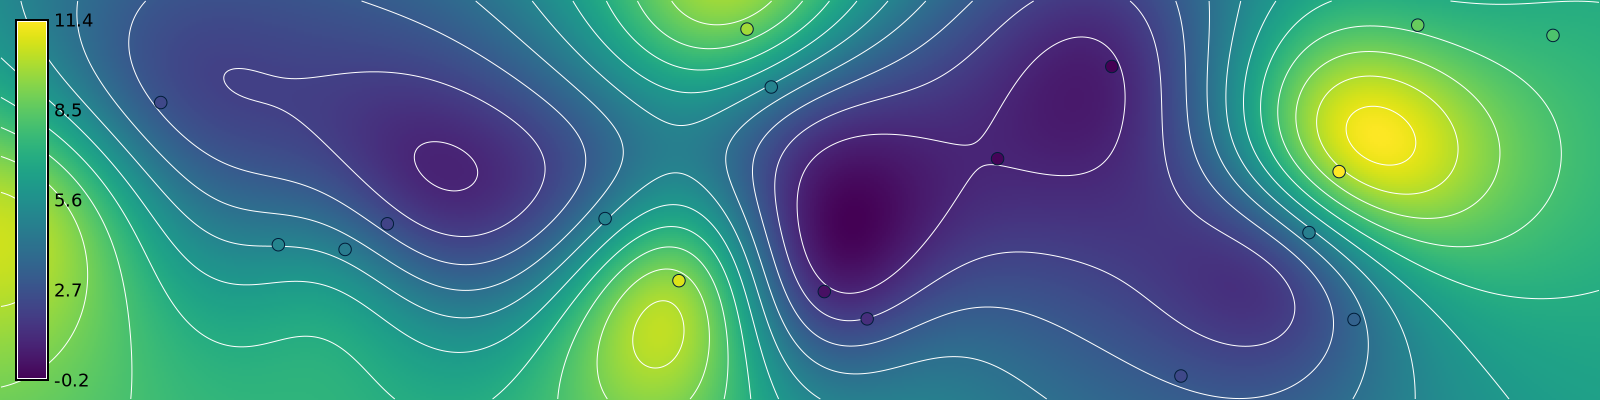
<figcaption aria-hidden="true">Regularized spline with tension
interpolation using optimized parameters</figcaption>
</figure>